# KOSPI 200 (20Y) — GJR-GARCH(1,1) + Skew-t 테스트 (Colab)

- 데이터: Yahoo Finance `^KS200` (KOSPI 200 Index)
- 기간: 최근 20년 (기본값: 오늘 기준 20년 전 ~ 오늘)
- 모델: **GJR-GARCH(1,1)** (ARCH 패키지에서는 `p=1, o=1, q=1`) + **Skew-t** 분포
- 산출물:
  - 적합 결과 요약
  - 1-step ahead 변동성 예측 (rolling fit)
  - 단순 평가(예측 변동성과 realized proxy 비교)
  - 1% VaR 백테스트(히트율, Kupiec POF)

> 참고: Colab 런타임/데이터 수급 상태에 따라 다운로드가 실패할 수 있습니다.


In [6]:
# ====== (1) Install deps ======
!pip -q install yfinance arch statsmodels


In [7]:
# ====== (2) Imports ======
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf

from arch import arch_model
from scipy import stats

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True


Corr(r^2, sig^2)   = 0.3567249114278574
Corr(rv20, sig)    = 0.8494867592585128
QLIKE (lower better) = -8.126877252903714


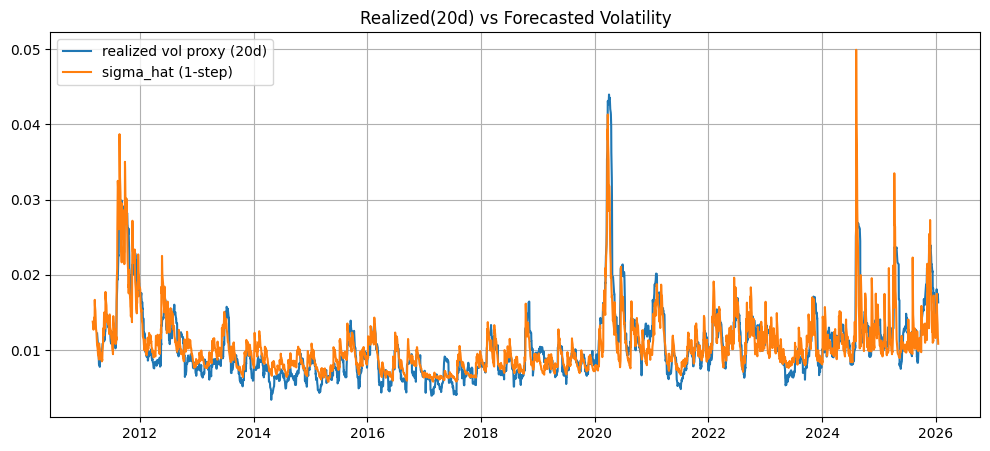

In [15]:
# ====== (3) Download data (20Y) — robust ======
TICKER = '^KS200'

end = pd.Timestamp.today(tz='Asia/Seoul').normalize()
start = (end - pd.DateOffset(years=20)).normalize()

raw = yf.download(
    TICKER,
    start=start.date(),
    end=(end + pd.Timedelta(days=1)).date(),
    auto_adjust=True,
    progress=False
)

if raw.empty:
    raise RuntimeError('데이터 다운로드 실패: 티커/네트워크 상태를 확인하세요.')

# yfinance가 MultiIndex 컬럼으로 주는 경우 대응
# 예: columns = MultiIndex([('Close','^KS200'), ('Open','^KS200'), ...])
if isinstance(raw.columns, pd.MultiIndex):
    close = raw['Close'].iloc[:, 0]   # Close 레벨의 첫 컬럼(보통 티커)
else:
    close = raw['Close']

df = pd.DataFrame({'Close': close}).dropna()
df.index = pd.to_datetime(df.index)
df.head(), df.tail(), (df.index.min(), df.index.max(), len(df))


In [9]:
# ====== (4) Returns ======
ret = np.log(df['Close']).diff().dropna()      # Series
y = (ret * 100.0)                              # Series
y.name = "logret_pct"
y.describe()


,logret_pct
count,4883.000000
mean,0.027697
std,1.297874
min,-10.902868
25%,-0.592321
50%,0.068345
75%,0.700742
max,11.539706


In [10]:
# ====== (5) Fit: GJR-GARCH(1,1) + Skew-t (full sample) ======
# GJR: p=1, o=1, q=1 with vol='GARCH'
am = arch_model(y, mean='Constant', vol='GARCH', p=1, o=1, q=1, dist='skewt')
res = am.fit(disp='off')
print(res.summary())


                         Constant Mean - GJR-GARCH Model Results                         
Dep. Variable:                        logret_pct   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GJR-GARCH   Log-Likelihood:               -7330.75
Distribution:      Standardized Skew Student's t   AIC:                           14675.5
Method:                       Maximum Likelihood   BIC:                           14721.0
                                                   No. Observations:                 4883
Date:                           Fri, Jan 16 2026   Df Residuals:                     4882
Time:                                   02:36:59   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
----------------------------------

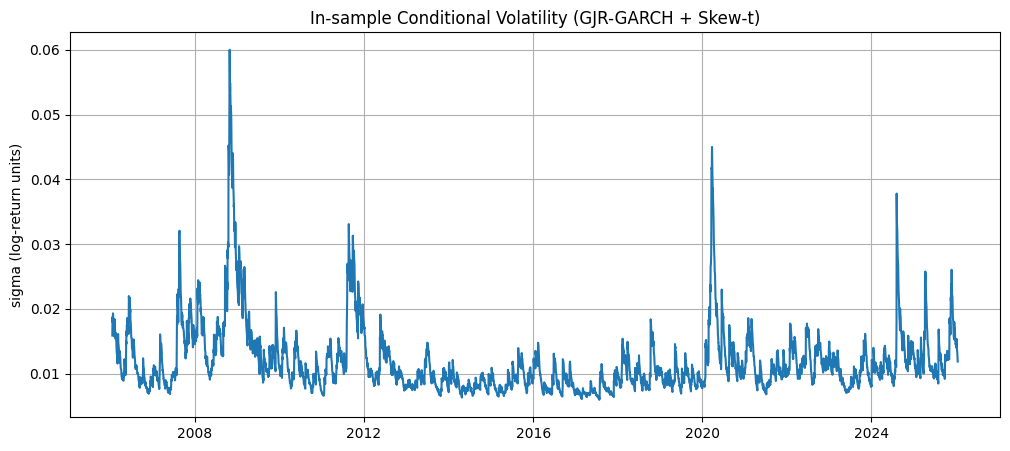

In [11]:
# ====== (6) In-sample conditional volatility plot ======
cond_vol = res.conditional_volatility / 100.0  # back to return units

fig = plt.figure()
plt.plot(cond_vol.index, cond_vol.values)
plt.title('In-sample Conditional Volatility (GJR-GARCH + Skew-t)')
plt.ylabel('sigma (log-return units)')
plt.show()


## Rolling 1-step ahead volatility forecast

아래는 **롤링 윈도우(기본 5년)** 로 매 시점에 재추정하여 **다음날 변동성(1-step)** 을 예측합니다.

- 윈도우를 키우면(예: 10년) 안정적이지만 레짐 반응이 느려질 수 있음
- 윈도우를 줄이면(예: 2~3년) 민감하지만 추정 노이즈/불안정 증가


In [12]:
# ====== (7) Rolling forecast setup ======
window_years = 5
min_obs = int(252 * window_years)

y_ = y.copy()
idx = y_.index

sigma_hat = pd.Series(index=idx, dtype=float)
mu_hat = pd.Series(index=idx, dtype=float)

# We'll forecast sigma_{t+1} using data up to t
for i in range(min_obs, len(y_)-1):
    train = y_.iloc[i-min_obs:i]
    try:
        m = arch_model(train, mean='Constant', vol='GARCH', p=1, o=1, q=1, dist='skewt')
        r = m.fit(disp='off', show_warning=False)
        f = r.forecast(horizon=1, reindex=False)
        # forecasted mean and variance for next step
        mu_next = float(r.params.get('mu', 0.0))
        var_next = float(f.variance.values[-1, 0])
        sigma_hat.iloc[i+1] = np.sqrt(var_next) / 100.0
        mu_hat.iloc[i+1] = mu_next / 100.0
    except Exception:
        # if estimation fails, leave NaN
        continue

sigma_hat = sigma_hat.dropna()
mu_hat = mu_hat.loc[sigma_hat.index]

sigma_hat.head(), sigma_hat.tail(), len(sigma_hat)


(Date
 2011-03-04    0.013771
 2011-03-07    0.013216
 2011-03-09    0.012704
 2011-03-10    0.013715
 2011-03-11    0.013147
 dtype: float64,
 Date
 2026-01-12    0.013374
 2026-01-13    0.012340
 2026-01-14    0.011581
 2026-01-15    0.011357
 2026-01-16    0.010831
 dtype: float64,
 3622)

Corr(r^2, sig^2)   = 0.3567249114278574
Corr(rv20, sig)    = 0.8494867592585128
QLIKE (lower better) = -8.126877252903714


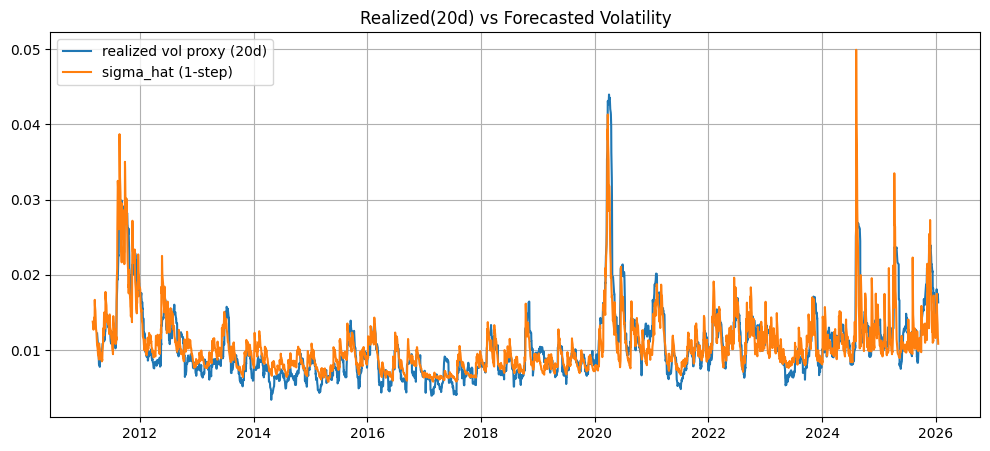

In [16]:
# ====== Better realized proxy + QLIKE ======
ret_aligned = ret.loc[sigma_hat.index]
sig = sigma_hat.loc[ret_aligned.index]

# realized proxy 1) r^2
rv1 = (ret_aligned**2).rename("r2")
sig2 = (sig**2).rename("sig2")

# realized proxy 2) 20D realized vol (annualize 안 함: 단위 맞추기 쉬움)
rv20 = np.sqrt(rv1.rolling(20).mean()).rename("rv20")
sig_aligned = sig.rename("sig")

# Corr 비교
print("Corr(r^2, sig^2)   =", rv1.corr(sig2))
print("Corr(rv20, sig)    =", rv20.corr(sig_aligned))

# QLIKE (분산 기준)
eps = 1e-12
qlike = (np.log(sig2 + eps) + (rv1 / (sig2 + eps))).mean()
print("QLIKE (lower better) =", qlike)

# Plot: rv20 vs sigma_hat
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(rv20.index, rv20.values, label="realized vol proxy (20d)")
plt.plot(sig_aligned.index, sig_aligned.values, label="sigma_hat (1-step)")
plt.title("Realized(20d) vs Forecasted Volatility")
plt.legend()
plt.grid(True)
plt.show()


## 1% VaR Backtest (Kupiec POF)

Skew-t 분포의 정확한 VaR는 파라미터(왜도/자유도)의 정의가 구현마다 달라서,
여기서는 **실전에서 흔히 쓰는 방식**처럼:

- 모델이 예측한 `mu_hat`, `sigma_hat`
- 분포는 t-분포(보수적 tail)로 근사

로 1% VaR를 만들고, **히트율과 Kupiec POF** 로 일단 점검합니다.

> 원하시면 arch의 skew-t 파라미터를 사용해 **정확한 skew-t VaR** 로 바꾸는 버전도 만들어드릴게요.


Hit rate (expected 1.00%) = 0.77%  (x=28, T=3622)
Kupiec POF: LR=2.044, p-value=0.1528


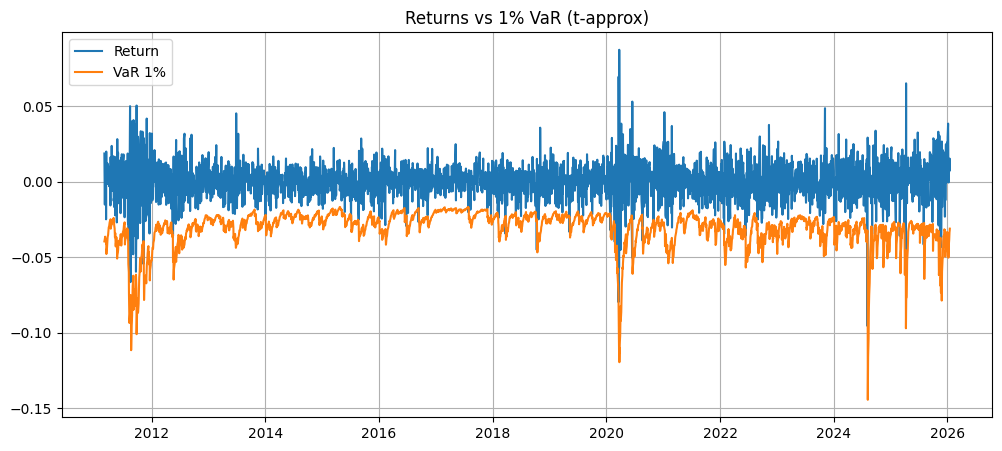

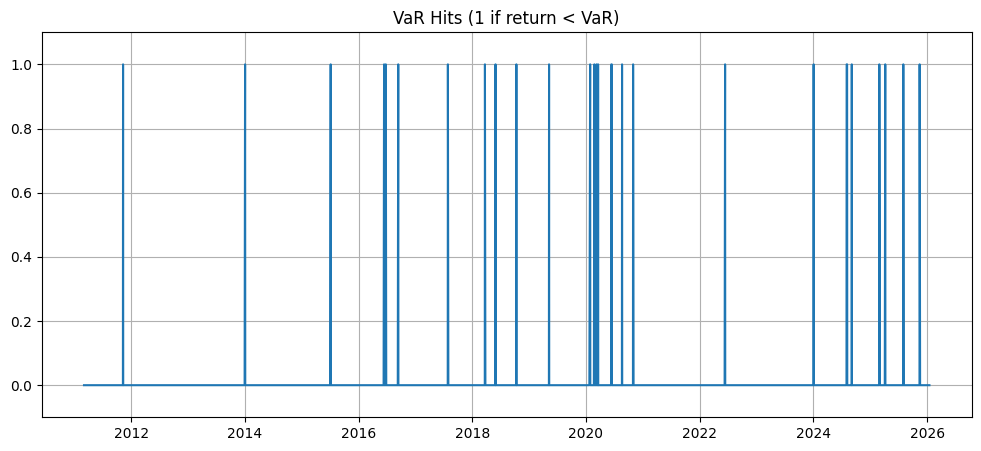

In [14]:
# ====== (9) 1% VaR backtest (t approx) ======
alpha = 0.01

# Use df from the full-sample fit as a stable tail parameter
# (Rolling마다 df 추정은 매우 불안정할 수 있음)
nu = float(res.params.get('nu', 8.0))  # fallback
q = stats.t.ppf(alpha, df=nu)  # left tail quantile

VaR = (mu_hat + sigma_hat * q).rename('VaR_1pct')
r_test = ret.loc[VaR.index].rename('ret')
hit = (r_test < VaR).astype(int).rename('hit')

hit_rate = hit.mean()
T = hit.shape[0]
x = int(hit.sum())

# Kupiec POF test
# LR = -2 * [ ln((1-a)^(T-x) a^x) - ln((1-x/T)^(T-x) (x/T)^x ) ]
a = alpha
p_hat = x / T if T > 0 else np.nan

def safe_log(z):
    return np.log(z) if z > 0 else -np.inf

L0 = (T-x)*safe_log(1-a) + x*safe_log(a)
L1 = (T-x)*safe_log(1-p_hat) + x*safe_log(p_hat)
LR = -2*(L0 - L1)
p_value = 1 - stats.chi2.cdf(LR, df=1)

print(f'Hit rate (expected {alpha:.2%}) = {hit_rate:.2%}  (x={x}, T={T})')
print(f'Kupiec POF: LR={LR:.3f}, p-value={p_value:.4f}')

fig = plt.figure()
plt.plot(r_test.index, r_test.values, label='Return')
plt.plot(VaR.index, VaR.values, label='VaR 1%')
plt.title('Returns vs 1% VaR (t-approx)')
plt.legend()
plt.show()

fig = plt.figure()
plt.plot(hit.index, hit.values)
plt.title('VaR Hits (1 if return < VaR)')
plt.ylim(-0.1, 1.1)
plt.show()


## 다음 단계 (원하면 바로 확장)

- **정확한 Skew-t VaR** (rolling 파라미터 기반)
- **모델 비교**: (i) GARCH+t vs (ii) GJR+t vs (iii) GJR+Skew-t
- **Out-of-sample log score** / **Diebold-Mariano**
- 레짐 기반(예: σ 분위수) 포지션 정책 테스트
